# E3 - Implementacion y evaluacion de modelos

En este notebook trabajo con los datos de ATUS de Sonora para implementar, evaluar y comparar modelos de mineria de datos. El objetivo es clasificar la gravedad de los accidentes y tambien encontrar grupos de municipios con comportamientos parecidos.

El periodo usado es de 10 años: **2015 a 2024**. La variable principal de clasificacion es `GRAVE_BIN`, donde `1` significa que el accidente tuvo personas heridas o fallecidas, y `0` significa que fue un accidente sin victimas.


## 1. Instalacion de librerias

Esta celda instala solamente las librerias que podrian faltar en Google Colab. Las librerias principales como pandas, numpy, matplotlib, seaborn y scikit-learn normalmente ya vienen instaladas.


In [1]:
import sys
import subprocess
import importlib.util


def ensure_package(import_name, pip_name=None):
    if importlib.util.find_spec(import_name) is None:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pip_name or import_name])


ensure_package("mlxtend")

## 2. Librerias y configuracion

Aqui cargo las librerias que se usan en todo el notebook. Tambien fijo una semilla aleatoria para que los resultados sean reproducibles.


In [2]:
from pathlib import Path
import os
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.cluster.hierarchy import dendrogram, linkage, fcluster

from sklearn.cluster import AgglomerativeClustering
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    davies_bouldin_score,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    RocCurveDisplay,
    silhouette_score,
)
from sklearn.model_selection import RandomizedSearchCV, train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier, export_text

from mlxtend.frequent_patterns import apriori, association_rules

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 120)
pd.set_option("display.max_rows", 100)
sns.set_theme(style="whitegrid", palette="Set2")

RANDOM_STATE = 42


## 3. Fuente de datos

El notebook esta preparado para funcionar en Google Colab tomando los archivos CSV desde GitHub. Si no hay internet, tambien puede usar una copia local del repositorio.


In [3]:
DATA_SOURCE = os.getenv("DATA_SOURCE", "auto")  # opciones: "auto", "github", "local"
GITHUB_BRANCH = "feature/notebook-atus-sonora-10-anios"
GITHUB_RAW_BASE = (
    "https://raw.githubusercontent.com/"
    f"andresdanvinchi/prevencion_vial_sonora_Sheeptech/{GITHUB_BRANCH}"
)
JSDELIVR_BASE = (
    "https://cdn.jsdelivr.net/gh/"
    f"andresdanvinchi/prevencion_vial_sonora_Sheeptech@{GITHUB_BRANCH}"
)


def find_local_project_dir():
    candidate_base_dirs = [
        Path.cwd(),
        Path.cwd().parent,
        Path("/content/prevencion_vial_sonora_Sheeptech"),
        Path("/content/drive/MyDrive/prevencion_vial_sonora_Sheeptech"),
    ]
    for base in candidate_base_dirs:
        if (base / "datos" / "originales" / "conjunto_de_datos").exists():
            return base
    return None


DATA_SOURCES = []
if DATA_SOURCE in ("auto", "github"):
    DATA_SOURCES.extend([
        {
            "name": "GitHub raw",
            "data_dir": f"{GITHUB_RAW_BASE}/datos/originales/conjunto_de_datos",
            "cat_dir": f"{GITHUB_RAW_BASE}/datos/originales/catalogos",
        },
        {
            "name": "jsDelivr CDN",
            "data_dir": f"{JSDELIVR_BASE}/datos/originales/conjunto_de_datos",
            "cat_dir": f"{JSDELIVR_BASE}/datos/originales/catalogos",
        },
    ])

if DATA_SOURCE in ("auto", "local"):
    PROJECT_DIR = find_local_project_dir()
    if PROJECT_DIR is not None:
        DATA_SOURCES.append({
            "name": "local",
            "data_dir": PROJECT_DIR / "datos" / "originales" / "conjunto_de_datos",
            "cat_dir": PROJECT_DIR / "datos" / "originales" / "catalogos",
        })

if not DATA_SOURCES:
    raise FileNotFoundError("No se encontro una fuente de datos disponible.")

print("Fuentes configuradas:")
for source in DATA_SOURCES:
    print("-", source["name"], ":", source["data_dir"])

Fuentes configuradas:
- GitHub raw : https://raw.githubusercontent.com/andresdanvinchi/prevencion_vial_sonora_Sheeptech/feature/notebook-atus-sonora-10-anios/datos/originales/conjunto_de_datos
- jsDelivr CDN : https://cdn.jsdelivr.net/gh/andresdanvinchi/prevencion_vial_sonora_Sheeptech@feature/notebook-atus-sonora-10-anios/datos/originales/conjunto_de_datos
- local : c:\Users\felip\Downloads\prevencion_vial_sonora_Sheeptech\datos\originales\conjunto_de_datos


## 4. Carga y preparacion del dataset

Cargo los 10 años de ATUS, filtro Sonora, elimino `Certificado cero` y construyo las variables necesarias para los modelos. Para aligerar el uso de memoria solo leo las columnas que se ocupan en este entregable.


In [4]:
YEARS = list(range(2015, 2025))
SONORA_ID = "26"
ACTIVE_SOURCE = None

dead_cols = ["CONDMUERTO", "PASAMUERTO", "PEATMUERTO", "CICLMUERTO", "OTROMUERTO", "NEMUERTO"]
injury_cols = ["CONDHERIDO", "PASAHERIDO", "PEATHERIDO", "CICLHERIDO", "OTROHERIDO", "NEHERIDO"]
vehicle_cols = [
    "AUTOMOVIL", "CAMPASAJ", "MICROBUS", "PASCAMION", "OMNIBUS", "TRANVIA",
    "CAMIONETA", "CAMION", "TRACTOR", "FERROCARRI", "MOTOCICLET", "BICICLETA", "OTROVEHIC"
]
base_cols = [
    "ID_ENTIDAD", "ID_MUNICIPIO", "ANIO", "MES", "ID_DIA", "ID_HORA", "ID_EDAD",
    "DIASEMANA", "TIPACCID", "CAUSAACCI", "CAPAROD", "SEXO", "ALIENTO", "CINTURON", "CLASACC"
]
usecols = base_cols + dead_cols + injury_cols + vehicle_cols


def data_path(base_dir, filename):
    if isinstance(base_dir, str):
        return f"{base_dir}/{filename}"
    return base_dir / filename


def read_csv_clean(path_or_url, usecols=None):
    df = pd.read_csv(
        path_or_url,
        dtype=str,
        usecols=usecols,
        skipinitialspace=True,
        encoding="utf-8",
        low_memory=False,
        index_col=False,
    )
    df.columns = df.columns.str.strip()
    for col in df.columns:
        df[col] = df[col].astype(str).str.strip()
        df[col] = df[col].replace({"nan": np.nan, "None": np.nan})
    return df


def read_csv_from_sources(filename, folder, usecols=None):
    global ACTIVE_SOURCE

    sources_to_try = []
    if ACTIVE_SOURCE is not None:
        sources_to_try.append(ACTIVE_SOURCE)
    sources_to_try.extend([source for source in DATA_SOURCES if source is not ACTIVE_SOURCE])

    errors = []
    for source in sources_to_try:
        base_dir = source["data_dir"] if folder == "data" else source["cat_dir"]
        path = data_path(base_dir, filename)
        if isinstance(path, Path) and not path.exists():
            errors.append(f'{source["name"]}: no existe {path}')
            continue
        try:
            df = read_csv_clean(path, usecols=usecols)
            ACTIVE_SOURCE = source
            return df
        except Exception as exc:
            errors.append(f'{source["name"]}: {type(exc).__name__}: {exc}')

    raise RuntimeError(
        "No se pudieron leer los datos. Si aparece 'Network is unreachable', el entorno no tiene internet. "
        "Sube la carpeta del proyecto a Colab o usa DATA_SOURCE = 'local'.\n\n"
        + "\n".join(errors[-6:])
    )


frames = []
for year in YEARS:
    tmp = read_csv_from_sources(f"atus_anual_{year}.csv", folder="data", usecols=usecols)
    entidad_norm = pd.to_numeric(tmp["ID_ENTIDAD"], errors="coerce").astype("Int64").astype(str).str.zfill(2)
    tmp = tmp[entidad_norm == SONORA_ID].copy()
    frames.append(tmp)

atus = pd.concat(frames, ignore_index=True)
atus = atus[atus["TIPACCID"].ne("Certificado cero")].copy()

mun = read_csv_from_sources("tc_municipio.csv", folder="cat")
mun["ID_ENTIDAD"] = pd.to_numeric(mun["ID_ENTIDAD"], errors="coerce").astype("Int64").astype(str).str.zfill(2)
mun["ID_MUNICIPIO"] = pd.to_numeric(mun["ID_MUNICIPIO"], errors="coerce").astype("Int64").astype(str).str.zfill(3)

atus["ID_ENTIDAD"] = pd.to_numeric(atus["ID_ENTIDAD"], errors="coerce").astype("Int64").astype(str).str.zfill(2)
atus["ID_MUNICIPIO"] = pd.to_numeric(atus["ID_MUNICIPIO"], errors="coerce").astype("Int64").astype(str).str.zfill(3)
atus = atus.merge(
    mun[["ID_ENTIDAD", "ID_MUNICIPIO", "NOM_MUNICIPIO"]],
    on=["ID_ENTIDAD", "ID_MUNICIPIO"],
    how="left",
)

for col in dead_cols + injury_cols + vehicle_cols + ["ANIO", "ID_HORA", "ID_DIA", "ID_EDAD"]:
    atus[col] = pd.to_numeric(atus[col], errors="coerce")

atus["TOTAL_MUERTOS"] = atus[dead_cols].fillna(0).sum(axis=1)
atus["TOTAL_HERIDOS"] = atus[injury_cols].fillna(0).sum(axis=1)
atus["TOTAL_VICTIMAS"] = atus["TOTAL_MUERTOS"] + atus["TOTAL_HERIDOS"]
atus["TOTAL_VEHICULOS"] = atus[vehicle_cols].fillna(0).sum(axis=1)
atus["INVOLUCRA_MOTO"] = (atus["MOTOCICLET"].fillna(0) > 0).astype(int)
atus["INVOLUCRA_BICI"] = (atus["BICICLETA"].fillna(0) > 0).astype(int)

atus["GRAVE_BIN"] = (
    (atus["TOTAL_VICTIMAS"] > 0) |
    (atus["CLASACC"].isin(["Fatal", "No fatal"]))
).astype(int)

atus["NIVEL_GRAVEDAD"] = np.select(
    [atus["TOTAL_MUERTOS"] > 0, atus["TOTAL_HERIDOS"] > 0],
    ["Fatal", "Con heridos"],
    default="Solo daños",
)

region_map = {
    "030": "Hermosillo",
    "002": "Frontera", "019": "Frontera", "027": "Frontera", "035": "Frontera",
    "039": "Frontera", "041": "Frontera", "043": "Frontera", "055": "Frontera",
    "058": "Frontera", "059": "Frontera", "060": "Frontera", "067": "Frontera",
    "004": "Costa y desierto", "007": "Costa y desierto", "017": "Costa y desierto",
    "046": "Costa y desierto", "047": "Costa y desierto", "048": "Costa y desierto",
    "064": "Costa y desierto", "065": "Costa y desierto", "070": "Costa y desierto",
    "001": "Centro", "006": "Centro", "013": "Centro", "014": "Centro", "016": "Centro",
    "020": "Centro", "021": "Centro", "022": "Centro", "023": "Centro", "024": "Centro",
    "028": "Centro", "034": "Centro", "037": "Centro", "038": "Centro", "045": "Centro",
    "050": "Centro", "053": "Centro", "054": "Centro", "056": "Centro", "057": "Centro",
    "063": "Centro", "066": "Centro", "068": "Centro",
    "003": "Sur y Valle", "012": "Sur y Valle", "018": "Sur y Valle", "025": "Sur y Valle",
    "026": "Sur y Valle", "029": "Sur y Valle", "033": "Sur y Valle", "042": "Sur y Valle",
    "049": "Sur y Valle", "051": "Sur y Valle", "071": "Sur y Valle", "072": "Sur y Valle",
    "005": "Sierra", "008": "Sierra", "009": "Sierra", "010": "Sierra", "011": "Sierra",
    "015": "Sierra", "031": "Sierra", "032": "Sierra", "040": "Sierra", "044": "Sierra",
    "052": "Sierra", "061": "Sierra", "062": "Sierra", "069": "Sierra",
}
atus["REGION"] = atus["ID_MUNICIPIO"].map(region_map).fillna("Otros municipios")

atus["HORA_VALIDA"] = atus["ID_HORA"].where(atus["ID_HORA"].between(0, 23))
atus["RANGO_HORA"] = pd.cut(
    atus["HORA_VALIDA"],
    bins=[-0.1, 5, 11, 17, 23],
    labels=["Madrugada", "Manana", "Tarde", "Noche"],
)
atus["EDAD_CONDUCTOR"] = atus["ID_EDAD"].where(atus["ID_EDAD"].between(12, 98))

print("Fuente activa:", ACTIVE_SOURCE["name"])
print("Registros usados:", len(atus))
display(atus[["ANIO", "NOM_MUNICIPIO", "REGION", "TIPACCID", "CAUSAACCI", "NIVEL_GRAVEDAD", "GRAVE_BIN"]].head())
display(atus["GRAVE_BIN"].value_counts(normalize=True).rename("proporcion"))


Fuente activa: GitHub raw
Registros usados: 183911


,ANIO,NOM_MUNICIPIO,REGION,TIPACCID,CAUSAACCI,NIVEL_GRAVEDAD,GRAVE_BIN
0,2015,Agua Prieta,Frontera,Colisión con vehículo automotor,Conductor,Con heridos,1
1,2015,Agua Prieta,Frontera,Colisión con motocicleta,Conductor,Con heridos,1
2,2015,Agua Prieta,Frontera,Colisión con vehículo automotor,Conductor,Solo daños,0
3,2015,Agua Prieta,Frontera,Colisión con peatón (atropellamiento),Conductor,Con heridos,1
4,2015,Agua Prieta,Frontera,Colisión con vehículo automotor,Conductor,Solo daños,0


GRAVE_BIN
0    0.83007
1    0.16993
Name: proporcion, dtype: float64

## 5. Preparacion para clasificacion

Para evitar fuga de informacion, no uso como predictores las columnas de heridos, muertos, victimas ni la clasificacion original del accidente. Esas variables ayudan a construir `GRAVE_BIN`, por lo que meterlas al modelo seria darle la respuesta.


In [5]:
model_df = atus.dropna(subset=["GRAVE_BIN"]).copy()

MAX_MODEL_ROWS = int(os.getenv("MAX_MODEL_ROWS", "60000"))
if len(model_df) > MAX_MODEL_ROWS:
    model_df, _ = train_test_split(
        model_df,
        train_size=MAX_MODEL_ROWS,
        random_state=RANDOM_STATE,
        stratify=model_df["GRAVE_BIN"],
    )
    model_df = model_df.reset_index(drop=True)

categorical_features = [
    "REGION", "NOM_MUNICIPIO", "MES", "DIASEMANA", "RANGO_HORA",
    "TIPACCID", "CAUSAACCI", "CAPAROD", "SEXO", "ALIENTO", "CINTURON"
]
numeric_features = ["EDAD_CONDUCTOR", "TOTAL_VEHICULOS", "INVOLUCRA_MOTO", "INVOLUCRA_BICI"]

X = model_df[categorical_features + numeric_features]
y = model_df["GRAVE_BIN"].astype(int)

preprocess = ColumnTransformer(
    transformers=[
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore", min_frequency=20)),
        ]), categorical_features),
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
        ]), numeric_features),
    ]
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=RANDOM_STATE, stratify=y
)

print("Filas usadas para modelos:", len(model_df))
print("Entrenamiento:", len(X_train), "Prueba:", len(X_test))
display(y.value_counts(normalize=True).rename("proporcion"))

Filas usadas para modelos: 60000
Entrenamiento: 45000 Prueba: 15000


GRAVE_BIN
0    0.830067
1    0.169933
Name: proporcion, dtype: float64

## 6. Funcion de evaluacion

Esta funcion calcula las metricas pedidas para clasificacion: accuracy, precision, recall, F1-score, matriz de confusion y curva ROC. En este proyecto pongo especial atencion al recall y al F1 de la clase grave, porque para prevencion es importante detectar accidentes con victimas.


In [6]:
classification_results = []


def evaluate_classifier(name, model, X_test, y_test):
    pred = model.predict(X_test)

    if hasattr(model, "predict_proba"):
        score = model.predict_proba(X_test)[:, 1]
    elif hasattr(model, "decision_function"):
        score = model.decision_function(X_test)
    else:
        score = None

    metrics = {
        "modelo": name,
        "accuracy": accuracy_score(y_test, pred),
        "precision_grave": precision_score(y_test, pred, pos_label=1, zero_division=0),
        "recall_grave": recall_score(y_test, pred, pos_label=1, zero_division=0),
        "f1_grave": f1_score(y_test, pred, pos_label=1, zero_division=0),
    }
    if score is not None:
        metrics["roc_auc"] = roc_auc_score(y_test, score)
    else:
        metrics["roc_auc"] = np.nan

    classification_results.append(metrics)

    print(name)
    print(pd.Series(metrics).drop("modelo").round(4))

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    ConfusionMatrixDisplay.from_predictions(
        y_test, pred, display_labels=["No grave", "Grave"], cmap="Blues", ax=axes[0]
    )
    axes[0].set_title(f"Matriz de confusion - {name}")

    if score is not None:
        RocCurveDisplay.from_predictions(y_test, score, ax=axes[1])
        axes[1].set_title(f"Curva ROC - {name}")
    else:
        axes[1].axis("off")

    plt.tight_layout()
    plt.show()

    return metrics

## 7. Modelo 1: Arbol de Decision como linea base

Uso un arbol de decision con parametros por defecto como linea base simple. Este modelo sirve para tener una primera referencia y comparar si los modelos mas elaborados realmente mejoran.


Arbol de Decision base
accuracy           0.8466
precision_grave    0.5491
recall_grave       0.5437
f1_grave           0.5464
roc_auc             0.726
dtype: object


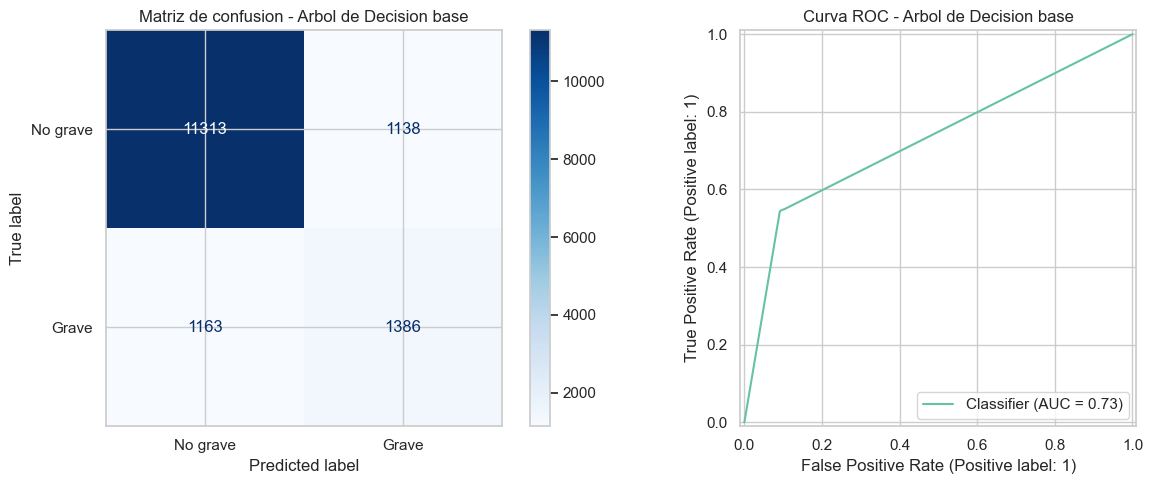

In [7]:
tree_baseline = Pipeline([
    ("preprocess", preprocess),
    ("model", DecisionTreeClassifier(random_state=RANDOM_STATE)),
])

tree_baseline.fit(X_train, y_train)
tree_metrics = evaluate_classifier("Arbol de Decision base", tree_baseline, X_test, y_test)

## 8. Regla IF-THEN del Arbol de Decision

El protocolo pide incluir una regla IF-THEN extraida del arbol. Para hacerlo, tomo el arbol entrenado como linea base y busco una ruta que termine en la clase grave. Esta regla no sustituye la evaluacion completa; sirve para explicar una decision del modelo de forma interpretable.


In [8]:
tree_feature_names = list(tree_baseline.named_steps["preprocess"].get_feature_names_out())
tree_model = tree_baseline.named_steps["model"]


def extract_first_positive_rule(decision_tree, feature_names, positive_label=1):
    tree = decision_tree.tree_
    classes = list(decision_tree.classes_)
    positive_idx = classes.index(positive_label)
    stack = [(0, [])]

    while stack:
        node_id, conditions = stack.pop()
        left_id = tree.children_left[node_id]
        right_id = tree.children_right[node_id]

        if left_id == right_id:
            values = tree.value[node_id][0]
            predicted_idx = int(np.argmax(values))
            if predicted_idx == positive_idx:
                probability = values[positive_idx] / values.sum()
                support = int(values.sum())
                return conditions, probability, support
            continue

        feature_name = feature_names[tree.feature[node_id]]
        threshold = tree.threshold[node_id]
        stack.append((right_id, conditions + [f"{feature_name} > {threshold:.3f}"]))
        stack.append((left_id, conditions + [f"{feature_name} <= {threshold:.3f}"]))

    return [], np.nan, 0


conditions, probability, support = extract_first_positive_rule(tree_model, tree_feature_names, positive_label=1)
print("Regla IF-THEN extraida del arbol:")
if conditions:
    print("IF " + " AND ".join(conditions))
    print(f"THEN GRAVE_BIN = 1 (Grave), probabilidad en hoja = {probability:.3f}, soporte = {support}")
else:
    print("No se encontro una hoja que prediga la clase grave en el arbol entrenado.")

print()
print("Primeros niveles del arbol para contexto:")
print(export_text(tree_model, feature_names=tree_feature_names, max_depth=3))


Regla IF-THEN extraida del arbol:
IF cat__TIPACCID_Colisión con peatón (atropellamiento) <= 0.500 AND num__INVOLUCRA_MOTO <= 1.164 AND num__INVOLUCRA_BICI <= 3.611 AND cat__TIPACCID_Caída de pasajero <= 0.500 AND cat__TIPACCID_Volcadura <= 0.500 AND cat__ALIENTO_Sí <= 0.500 AND cat__CINTURON_Se ignora <= 0.500 AND cat__REGION_Sur y Valle <= 0.500 AND cat__NOM_MUNICIPIO_San Luis Río Colorado <= 0.500 AND cat__TIPACCID_Colisión con vehículo automotor <= 0.500 AND num__EDAD_CONDUCTOR <= 2.736 AND num__EDAD_CONDUCTOR <= -1.632 AND cat__CINTURON_No > 0.500
THEN GRAVE_BIN = 1 (Grave), probabilidad en hoja = 1.000, soporte = 1

Primeros niveles del arbol para contexto:
|--- cat__TIPACCID_Colisión con peatón (atropellamiento) <= 0.50
|   |--- num__INVOLUCRA_MOTO <= 1.16
|   |   |--- num__INVOLUCRA_BICI <= 3.61
|   |   |   |--- cat__TIPACCID_Caída de pasajero <= 0.50
|   |   |   |   |--- truncated branch of depth 55
|   |   |   |--- cat__TIPACCID_Caída de pasajero >  0.50
|   |   |   |   |--- c

## 9. Modelo 2: KNN linea base

KNN se incluye como linea base adicional porque es uno de los metodos estudiados en el curso. Como el dataset es grande y KNN compara observaciones cercanas, uso muestras estratificadas para que la celda pueda ejecutarse en Colab sin volver demasiado lenta la evaluacion.


KNN linea base
accuracy            0.865
precision_grave    0.6895
recall_grave       0.3737
f1_grave           0.4847
roc_auc            0.7865
dtype: object


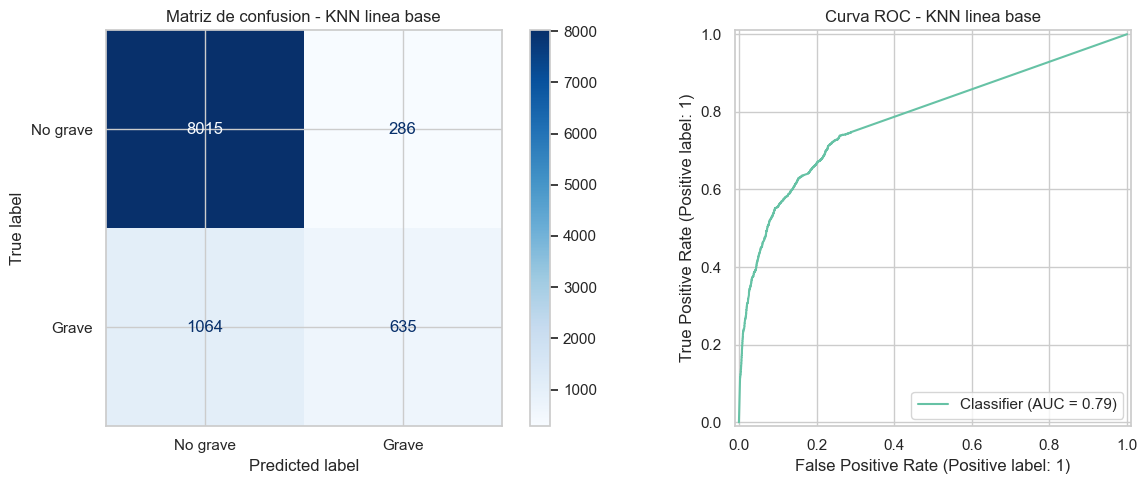

In [9]:
MAX_KNN_TRAIN_ROWS = int(os.getenv("MAX_KNN_TRAIN_ROWS", "15000"))
MAX_KNN_TEST_ROWS = int(os.getenv("MAX_KNN_TEST_ROWS", "10000"))

if len(X_train) > MAX_KNN_TRAIN_ROWS:
    X_knn_train, _, y_knn_train, _ = train_test_split(
        X_train,
        y_train,
        train_size=MAX_KNN_TRAIN_ROWS,
        random_state=RANDOM_STATE,
        stratify=y_train,
    )
else:
    X_knn_train, y_knn_train = X_train, y_train

if len(X_test) > MAX_KNN_TEST_ROWS:
    X_knn_test, _, y_knn_test, _ = train_test_split(
        X_test,
        y_test,
        train_size=MAX_KNN_TEST_ROWS,
        random_state=RANDOM_STATE,
        stratify=y_test,
    )
else:
    X_knn_test, y_knn_test = X_test, y_test

knn_model = Pipeline([
    ("preprocess", preprocess),
    ("model", KNeighborsClassifier(n_neighbors=5, weights="distance")),
])

knn_model.fit(X_knn_train, y_knn_train)
knn_metrics = evaluate_classifier("KNN linea base", knn_model, X_knn_test, y_knn_test)


KNN permite comparar contra un metodo simple basado en cercania entre registros. En este proyecto funciona como referencia de curso: ayuda a saber si una estrategia por vecinos compite contra modelos mas adecuados para datos mixtos y de alta dimensionalidad.


## 10. Modelo 3: Regresion Logistica interpretable

La regresion logistica funciona como modelo supervisado interpretable. Uso `class_weight="balanced"` para darle mas importancia a la clase grave, porque aparece menos que la clase no grave.


Regresion Logistica
accuracy           0.8229
precision_grave    0.4861
recall_grave       0.7387
f1_grave           0.5863
roc_auc            0.8806
dtype: object


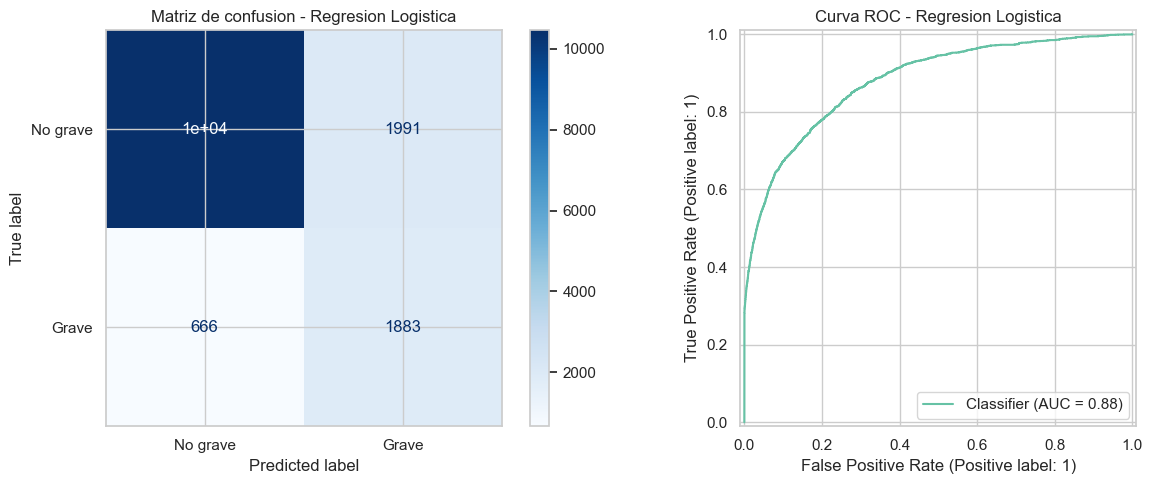

In [10]:
log_model = Pipeline([
    ("preprocess", preprocess),
    ("model", LogisticRegression(max_iter=1000, class_weight="balanced")),
])

log_model.fit(X_train, y_train)
log_metrics = evaluate_classifier("Regresion Logistica", log_model, X_test, y_test)

## 11. Modelo 4: Random Forest con ajuste de hiperparametros

Este es el modelo mas elaborado de clasificacion. Uso `RandomizedSearchCV` para probar varias combinaciones de hiperparametros y seleccionar la que tenga mejor F1 para la clase grave.


Fitting 3 folds for each of 6 candidates, totalling 18 fits
Mejores hiperparametros:


{'model__n_estimators': 120,
 'model__min_samples_leaf': 3,
 'model__max_features': 'sqrt',
 'model__max_depth': 20,
 'model__class_weight': 'balanced_subsample'}

Random Forest ajustado
accuracy             0.86
precision_grave    0.5719
recall_grave       0.7007
f1_grave           0.6298
roc_auc            0.8911
dtype: object


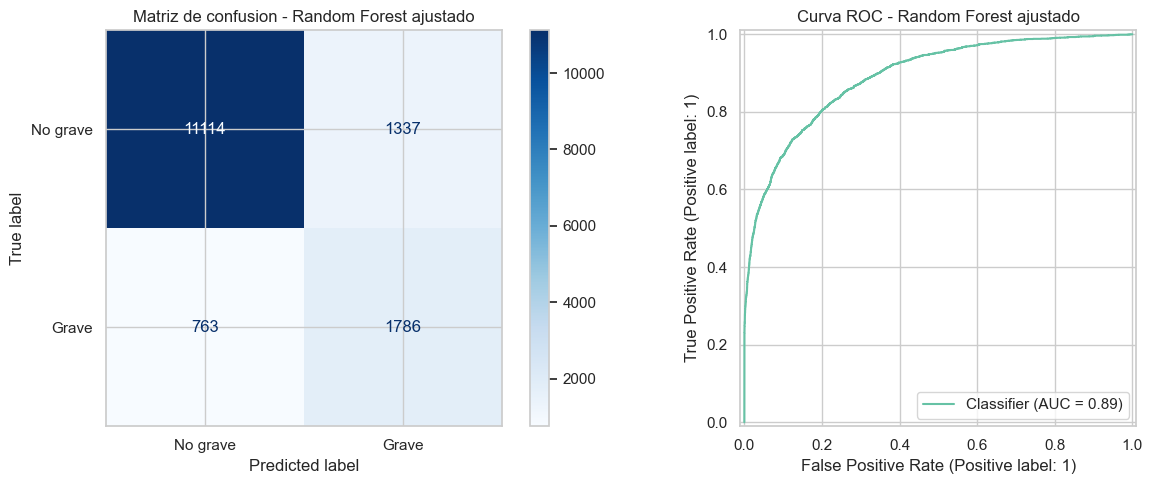

In [11]:
rf_pipeline = Pipeline([
    ("preprocess", preprocess),
    ("model", RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1)),
])

param_distributions = {
    "model__n_estimators": [120, 200],
    "model__max_depth": [None, 12, 20],
    "model__min_samples_leaf": [1, 3, 5],
    "model__max_features": ["sqrt", "log2"],
    "model__class_weight": ["balanced", "balanced_subsample"],
}

rf_search = RandomizedSearchCV(
    rf_pipeline,
    param_distributions=param_distributions,
    n_iter=6,
    scoring="f1",
    cv=3,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=1,
)

rf_search.fit(X_train, y_train)
print("Mejores hiperparametros:")
display(rf_search.best_params_)

rf_model = rf_search.best_estimator_
rf_metrics = evaluate_classifier("Random Forest ajustado", rf_model, X_test, y_test)

## 12. Importancia de variables del Random Forest

Esta parte ayuda a interpretar el modelo mas elaborado. La importancia de variables muestra que caracteristicas pesan mas al distinguir accidentes graves y no graves.


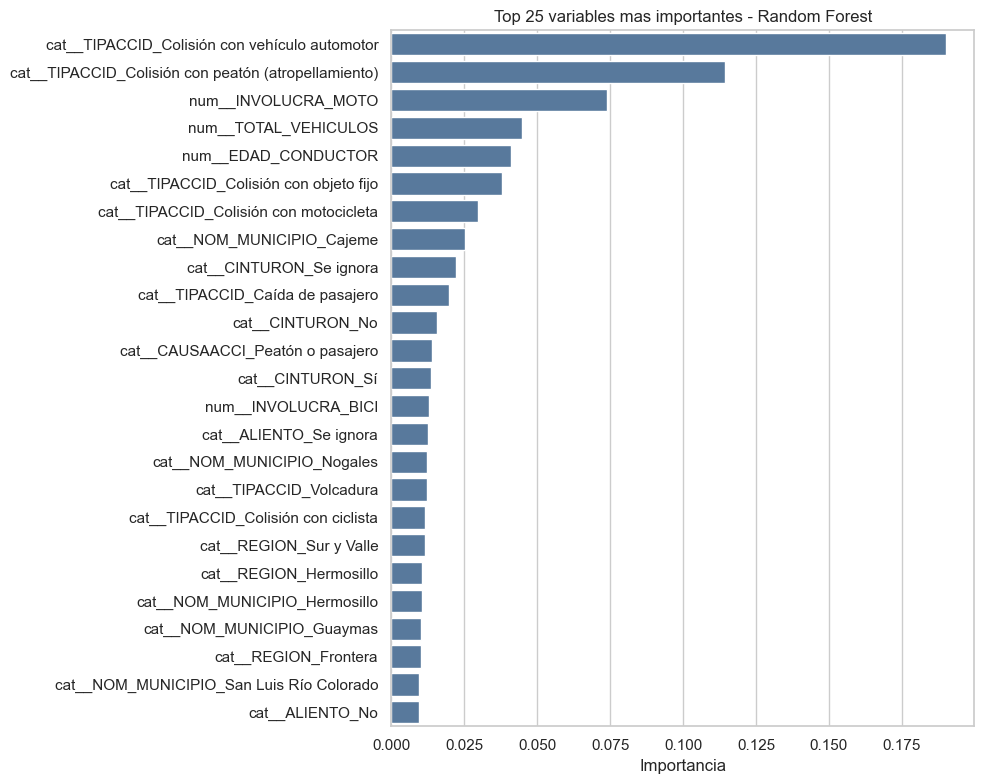

,variable,importancia
75,cat__TIPACCID_Colisión con vehículo automotor,0.190255
74,cat__TIPACCID_Colisión con peatón (atropellami...,0.114222
98,num__INVOLUCRA_MOTO,0.074011
97,num__TOTAL_VEHICULOS,0.044789
96,num__EDAD_CONDUCTOR,0.040990
73,cat__TIPACCID_Colisión con objeto fijo,0.037782
72,cat__TIPACCID_Colisión con motocicleta,0.029790
14,cat__NOM_MUNICIPIO_Cajeme,0.025253
94,cat__CINTURON_Se ignora,0.021966
69,cat__TIPACCID_Caída de pasajero,0.019777


In [12]:
feature_names = rf_model.named_steps["preprocess"].get_feature_names_out()
importances = rf_model.named_steps["model"].feature_importances_

importance_df = (
    pd.DataFrame({"variable": feature_names, "importancia": importances})
    .sort_values("importancia", ascending=False)
    .head(25)
)

plt.figure(figsize=(10, 8))
sns.barplot(data=importance_df, y="variable", x="importancia", color="#4C78A8")
plt.title("Top 25 variables mas importantes - Random Forest")
plt.xlabel("Importancia")
plt.ylabel("")
plt.tight_layout()
plt.show()

display(importance_df)


## 13. Modelo 5: Clustering jerarquico de municipios

Como tercer enfoque de naturaleza diferente, aplico clustering jerarquico. En lugar de clasificar accidentes individuales, agrupo municipios segun su comportamiento: volumen de accidentes, porcentaje de gravedad, motocicletas, bicicletas, vehiculos promedio y tipos de accidente.


,k,silhouette,davies_bouldin,cohesion_interna
4,6,0.286894,1.045528,375.720031
3,5,0.279132,1.119599,434.188014
2,4,0.253523,1.187132,514.824249
0,2,0.234067,1.554926,691.269196
1,3,0.228405,1.231758,602.691930


Numero de clusters seleccionado: 6


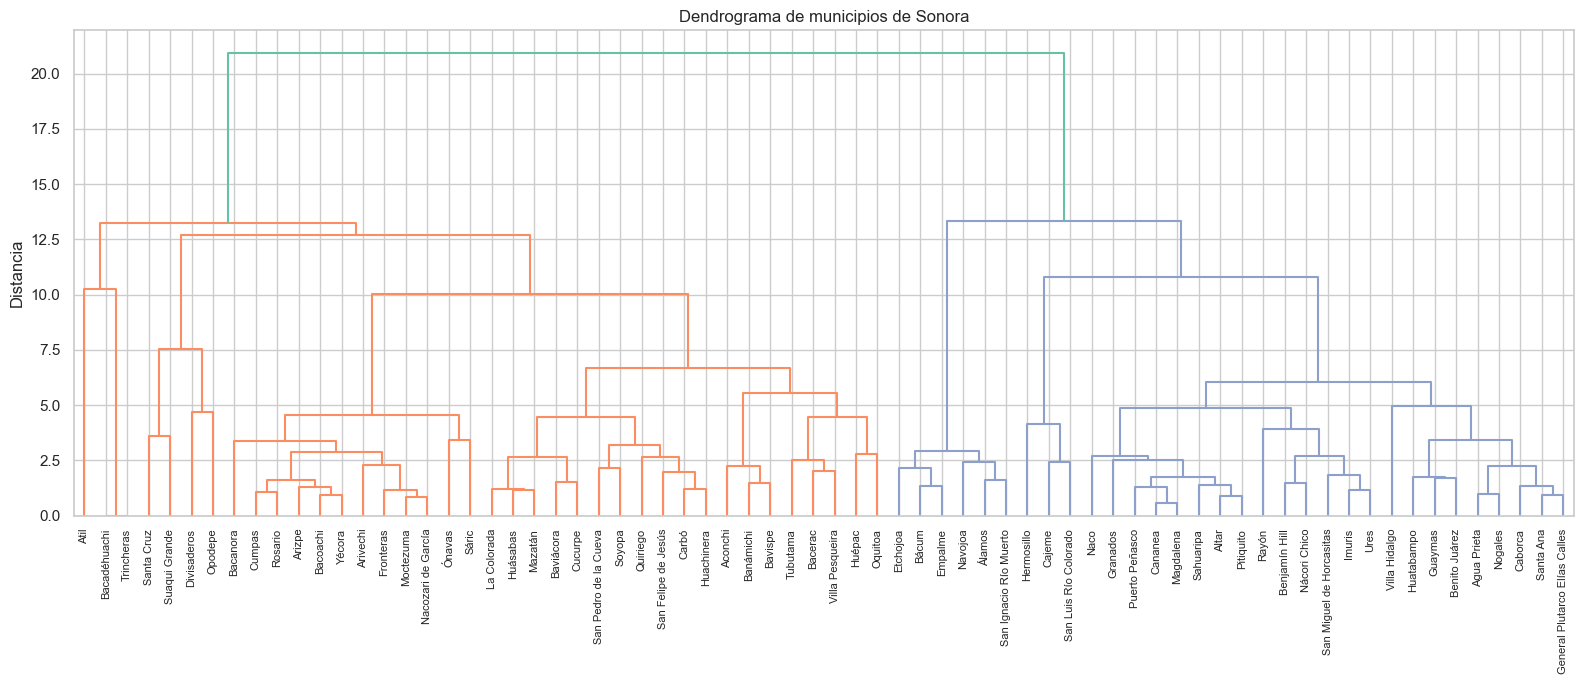

,municipios,accidentes,pct_graves,heridos_prom,muertos_prom,pct_moto,vehiculos_prom
CLUSTER,,,,,,,
1,3,4,1.0000,0.0000,1.0000,0.0000,1.0000
2,4,15,0.6917,0.5917,0.2667,0.1333,1.1958
3,31,3333,0.4070,0.6772,0.1383,0.0494,1.3130
4,6,8515,0.4612,0.5694,0.0556,0.3567,1.7755
5,3,129657,0.1190,0.1439,0.0071,0.1244,1.9286
6,23,42387,0.2483,0.3271,0.0384,0.0717,1.7421


,ID_MUNICIPIO,NOM_MUNICIPIO,REGION,accidentes,pct_graves,heridos_prom,muertos_prom,pct_moto,pct_bici,vehiculos_prom,pct_tipo_Colisión con vehículo automotor,pct_tipo_Colisión con motocicleta,pct_tipo_Colisión con objeto fijo,pct_tipo_Colisión con peatón (atropellamiento),pct_tipo_Volcadura,pct_tipo_Salida del camino,CLUSTER
61,064,Trincheras,Costa y desierto,2,1.000000,0.000000,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1
6,007,Atil,Costa y desierto,1,1.000000,0.000000,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1
7,008,Bacadéhuachi,Sierra,1,1.000000,0.000000,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1
60,062,Suaqui Grande,Sierra,5,0.600000,0.200000,0.400000,0.200000,0.000000,1.200000,0.000000,0.200000,0.000000,0.400000,0.200000,0.000000,2
44,045,Opodepe,Centro,4,0.500000,0.500000,0.000000,0.000000,0.000000,1.250000,0.250000,0.000000,0.250000,0.250000,0.000000,0.250000,2
23,024,Divisaderos,Centro,3,1.000000,0.666667,0.666667,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.333333,0.333333,0.333333,2
57,059,Santa Cruz,Frontera,3,0.666667,1.000000,0.000000,0.333333,0.000000,1.333333,0.000000,0.333333,0.000000,0.333333,0.333333,0.000000,2
40,041,Nacozari de García,Frontera,673,0.142645,0.208024,0.008915,0.017831,0.001486,1.554235,0.490342,0.005944,0.145617,0.010401,0.144131,0.157504,3
37,038,Moctezuma,Centro,509,0.086444,0.092338,0.029470,0.027505,0.000000,1.442043,0.388998,0.015717,0.123772,0.011788,0.180747,0.192534,3
26,027,Fronteras,Frontera,476,0.226891,0.292017,0.039916,0.033613,0.002101,1.403361,0.331933,0.014706,0.109244,0.018908,0.220588,0.216387,3


In [13]:
municipal = (
    atus.groupby(["ID_MUNICIPIO", "NOM_MUNICIPIO", "REGION"])
    .agg(
        accidentes=("GRAVE_BIN", "size"),
        pct_graves=("GRAVE_BIN", "mean"),
        heridos_prom=("TOTAL_HERIDOS", "mean"),
        muertos_prom=("TOTAL_MUERTOS", "mean"),
        pct_moto=("INVOLUCRA_MOTO", "mean"),
        pct_bici=("INVOLUCRA_BICI", "mean"),
        vehiculos_prom=("TOTAL_VEHICULOS", "mean"),
    )
    .reset_index()
)

top_tipos = atus["TIPACCID"].value_counts().head(6).index.tolist()
tipo_pivot = (
    pd.crosstab(atus["ID_MUNICIPIO"], atus["TIPACCID"], normalize="index")
    .reindex(columns=top_tipos, fill_value=0)
    .add_prefix("pct_tipo_")
    .reset_index()
)

municipal = municipal.merge(tipo_pivot, on="ID_MUNICIPIO", how="left").fillna(0)

cluster_features = [
    "accidentes", "pct_graves", "heridos_prom", "muertos_prom", "pct_moto",
    "pct_bici", "vehiculos_prom"
] + [c for c in municipal.columns if c.startswith("pct_tipo_")]

scaler = StandardScaler()
X_cluster = scaler.fit_transform(municipal[cluster_features])


def internal_cohesion(X_values, labels):
    total = 0.0
    for label in np.unique(labels):
        points = X_values[labels == label]
        centroid = points.mean(axis=0)
        total += ((points - centroid) ** 2).sum()
    return total


cluster_eval = []
for k in range(2, 7):
    clusterer = AgglomerativeClustering(n_clusters=k, linkage="ward")
    labels = clusterer.fit_predict(X_cluster)
    cluster_eval.append({
        "k": k,
        "silhouette": silhouette_score(X_cluster, labels),
        "davies_bouldin": davies_bouldin_score(X_cluster, labels),
        "cohesion_interna": internal_cohesion(X_cluster, labels),
    })

cluster_eval_df = pd.DataFrame(cluster_eval).sort_values(["silhouette", "davies_bouldin"], ascending=[False, True])
display(cluster_eval_df)

best_k = int(cluster_eval_df.iloc[0]["k"])
print("Numero de clusters seleccionado:", best_k)

Z = linkage(X_cluster, method="ward")
plt.figure(figsize=(16, 7))
dendrogram(Z, labels=municipal["NOM_MUNICIPIO"].values, leaf_rotation=90, leaf_font_size=8)
plt.title("Dendrograma de municipios de Sonora")
plt.ylabel("Distancia")
plt.tight_layout()
plt.show()

municipal["CLUSTER"] = fcluster(Z, t=best_k, criterion="maxclust")

cluster_profile = (
    municipal.groupby("CLUSTER")
    .agg(
        municipios=("NOM_MUNICIPIO", "count"),
        accidentes=("accidentes", "sum"),
        pct_graves=("pct_graves", "mean"),
        heridos_prom=("heridos_prom", "mean"),
        muertos_prom=("muertos_prom", "mean"),
        pct_moto=("pct_moto", "mean"),
        vehiculos_prom=("vehiculos_prom", "mean"),
    )
    .round(4)
)

display(cluster_profile)
display(municipal.sort_values(["CLUSTER", "accidentes"], ascending=[True, False]).head(70))

## 14. Reglas de asociacion como complemento preventivo

Las reglas de asociacion no sustituyen a los modelos de clasificacion, pero ayudan a encontrar combinaciones frecuentes de condiciones que terminan en accidentes graves. Por eso las uso como complemento interpretativo.


In [14]:
rule_df = atus[["REGION", "TIPACCID", "CAUSAACCI", "RANGO_HORA", "DIASEMANA", "GRAVE_BIN"]].copy()
rule_df["GRAVEDAD"] = np.where(rule_df["GRAVE_BIN"].eq(1), "Grave", "No grave")
rule_df = rule_df.drop(columns=["GRAVE_BIN"]).astype("object").fillna("No especificado").astype(str)

MAX_RULE_ROWS = int(os.getenv("MAX_RULE_ROWS", "50000"))
if len(rule_df) > MAX_RULE_ROWS:
    rule_df = rule_df.sample(MAX_RULE_ROWS, random_state=RANDOM_STATE)

rule_items = pd.get_dummies(rule_df, prefix=rule_df.columns, prefix_sep="=")
frequent_itemsets = apriori(rule_items, min_support=0.03, use_colnames=True)
rules = association_rules(frequent_itemsets, metric="confidence", min_threshold=0.35)

target_rules = rules[
    rules["consequents"].apply(lambda x: "GRAVEDAD=Grave" in x)
].copy()

target_rules["antecedents_txt"] = target_rules["antecedents"].apply(lambda x: ", ".join(sorted(x)))
target_rules["consequents_txt"] = target_rules["consequents"].apply(lambda x: ", ".join(sorted(x)))

top_rules = target_rules[
    ["antecedents_txt", "consequents_txt", "support", "confidence", "lift"]
].sort_values(["lift", "confidence", "support"], ascending=False).head(15)

display(top_rules)

,antecedents_txt,consequents_txt,support,confidence,lift
35,TIPACCID=Colisión con peatón (atropellamiento),GRAVEDAD=Grave,0.03774,1.000000,5.813278
258,TIPACCID=Colisión con motocicleta,"CAUSAACCI=Conductor, GRAVEDAD=Grave",0.03660,0.358894,2.315743
31,TIPACCID=Colisión con motocicleta,GRAVEDAD=Grave,0.03688,0.361640,2.102311
257,"CAUSAACCI=Conductor, TIPACCID=Colisión con mot...",GRAVEDAD=Grave,0.03660,0.360449,2.095391


## 15. Comparativa de modelos

En esta tabla comparo los modelos de clasificacion lado a lado. La recomendacion se fundamenta principalmente en F1 y ROC-AUC, pero en el contexto preventivo tambien reviso el recall de la clase grave.


In [15]:
comparativa = pd.DataFrame(classification_results)
for col in ["accuracy", "precision_grave", "recall_grave", "f1_grave", "roc_auc"]:
    comparativa[col] = comparativa[col].round(4)

display(comparativa.sort_values("f1_grave", ascending=False))

best_f1 = comparativa.sort_values(["f1_grave", "roc_auc"], ascending=False).iloc[0]
best_recall = comparativa.sort_values(["recall_grave", "f1_grave"], ascending=False).iloc[0]

print(f"Modelo recomendado por balance general: {best_f1['modelo']}")
print(f"Motivo: tiene el mejor F1 para accidentes graves ({best_f1['f1_grave']}) y ROC-AUC de {best_f1['roc_auc']}.")
print(f"Si la prioridad fuera detectar la mayor cantidad posible de accidentes graves, el modelo con mayor recall seria: {best_recall['modelo']} ({best_recall['recall_grave']}).")

,modelo,accuracy,precision_grave,recall_grave,f1_grave,roc_auc
3,Random Forest ajustado,0.8600,0.5719,0.7007,0.6298,0.8911
2,Regresion Logistica,0.8229,0.4861,0.7387,0.5863,0.8806
0,Arbol de Decision base,0.8466,0.5491,0.5437,0.5464,0.7260
1,KNN linea base,0.8650,0.6895,0.3737,0.4847,0.7865


Modelo recomendado por balance general: Random Forest ajustado
Motivo: tiene el mejor F1 para accidentes graves (0.6298) y ROC-AUC de 0.8911.
Si la prioridad fuera detectar la mayor cantidad posible de accidentes graves, el modelo con mayor recall seria: Regresion Logistica (0.7387).


## 16. Interpretacion final

Con estos resultados puedo comparar modelos desde dos puntos de vista. Para clasificacion, el mejor modelo es el que logra mejor equilibrio entre precision y recall en la clase grave, porque no basta con acertar muchos accidentes no graves. En seguridad vial, los errores mas delicados son los accidentes graves que el modelo no detecta.

El Random Forest ajustado es el candidato mas fuerte cuando se busca balance general: en la ejecucion documentada obtuvo el mejor F1 para la clase grave y un ROC-AUC alto. La regresion logistica sigue siendo valiosa porque suele alcanzar mayor recall de accidentes graves y es mas facil de explicar. KNN funciona como linea base del curso, y la Regla IF-THEN del arbol aporta una explicacion sencilla de una ruta de decision; ninguno desplaza la recomendacion final.

El clustering jerarquico aporta otra lectura: permite identificar municipios con perfiles parecidos. Esto ayuda a proponer estrategias por grupo de municipios, no solamente por accidente individual. Las reglas de asociacion complementan la interpretacion al mostrar que los atropellamientos o colisiones con peaton se relacionan fuertemente con gravedad alta.

La conclusion preventiva es que los modelos no deben verse solo como predictores, sino como herramientas para priorizar acciones: regiones de alto volumen, municipios con alta gravedad proporcional, horarios criticos y tipos de accidente con mayor impacto humano.
